<center><h1>Detecting Malaria using Convolutional Neural Network</h1></center>
 


# Importing necessary libraries

In [1]:
import os
print(os.getcwd())

c:\Users\bryan\Downloads\PROJ-H419 - Biomedical engineering project in image analysis - 202526\PROJ-H419


In [ ]:
from __future__ import absolute_import, division, print_function
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import TensorBoard
from sklearn.model_selection import KFold

import itertools
from PIL import Image
import albumentations as A
import os
import time
print(os.listdir("input/cell_images"))

NAME = "cnn3264128{}".format(int(time.time())%10)
log_dir = os.path.join("logs", NAME)
tensorboard = TensorBoard(log_dir= log_dir)

['cell_images', 'Parasitized', 'Uninfected']


# Data Exploration and Preprocessing

In [3]:
# Path to images
try :
    infected = os.listdir('input/cell_images/Parasitized/') 
    uninfected = os.listdir('input/cell_images/Uninfected/')
except FileNotFoundError:
    print('File not found')
    infected = []
    uninfected = [] 

In [4]:
data_path = []
labels = []
sizes_w = []
sizes_h = []

# Store Images path and associated label
def process_images(file_list, directory, label_value):
    for file_name in file_list:
        # Test to see if it is an image
        if not file_name.lower().endswith('.png'):
            continue 
        full_path = os.path.join(directory, file_name)
        try:
            with Image.open(full_path) as img:
                width, height = img.size
                sizes_w.append(width)
                sizes_h.append(height)
                data_path.append(full_path)
                labels.append(label_value)
        except Exception as e:
            print(f"Not an image : {full_path} ({e})")


print("Parasitized ")
process_images(infected, 'input/cell_images/Parasitized/', 1)

print("Uninfected ")
process_images(uninfected, 'input/cell_images/Uninfected/', 0)

# Statistics
if len(sizes_w) > 0:
    print("-" * 30)
    print(f"Total images : {len(data_path)}")
    print(f"Min width : {min(sizes_w)}")
    print(f"Min height : {min(sizes_h)}")
    print(f"Max width : {max(sizes_w)}")
    print(f"Max height : {max(sizes_h)}")
    
    avg_width = np.mean(sizes_w)
    avg_height = np.mean(sizes_h)
    print(f"Average size : {int(avg_width)} x {int(avg_height)}")
else:
    print("No images.")

Parasitized 
Uninfected 
------------------------------
Total images : 27558
Min width : 46
Min height : 40
Max width : 394
Max height : 385
Average size : 132 x 132


In [5]:
cells_path = np.array(data_path)
labels = np.array(labels)

In [6]:
print('Cells : {} | labels : {}'.format(cells_path.shape , labels.shape))

Cells : (27558,) | labels : (27558,)


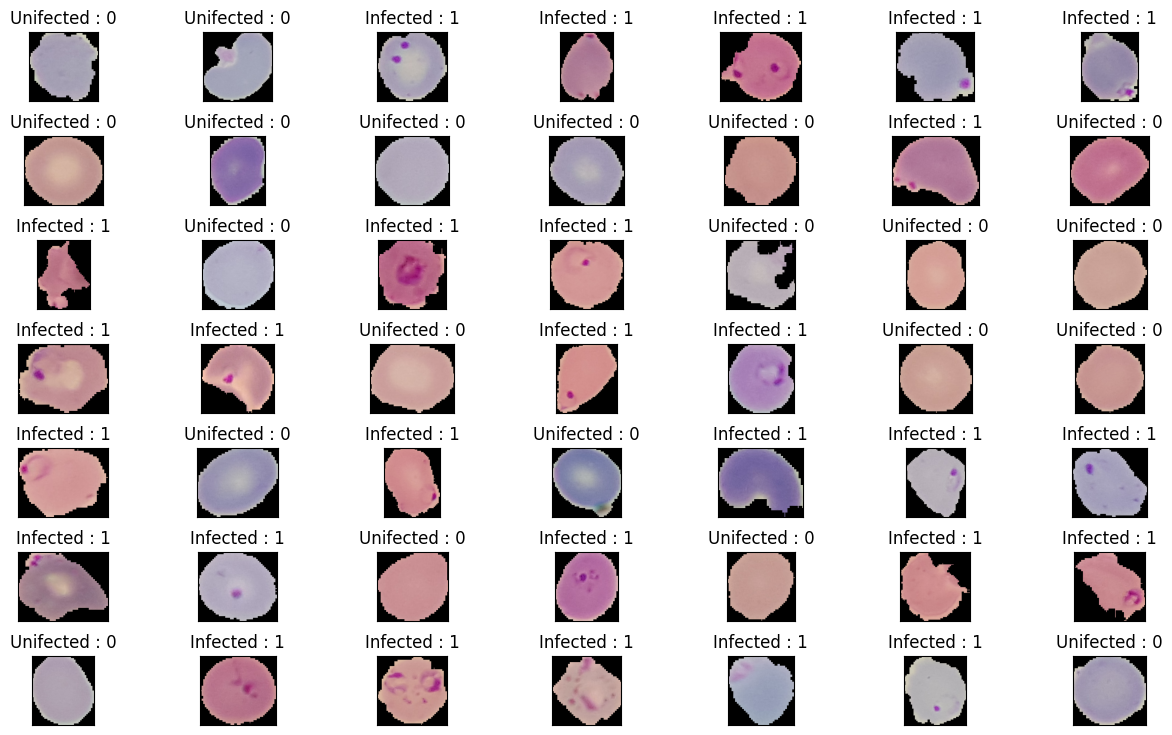

In [7]:
# Show samples of data
plt.figure(1 , figsize = (15 , 9))
n = 0 
for i in range(49):
    n += 1 
    r = np.random.randint(0 , cells_path.shape[0] , 1)
    plt.subplot(7 , 7 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    img =cv2.imread(cells_path[r[0]])
    img = img[:, :, ::-1]
    plt.imshow(img)
    plt.title('{} : {}'.format('Infected' if labels[r[0]] == 1 else 'Unifected' ,
                               labels[r[0]]) )
    plt.xticks([]) , plt.yticks([])
    
plt.show()

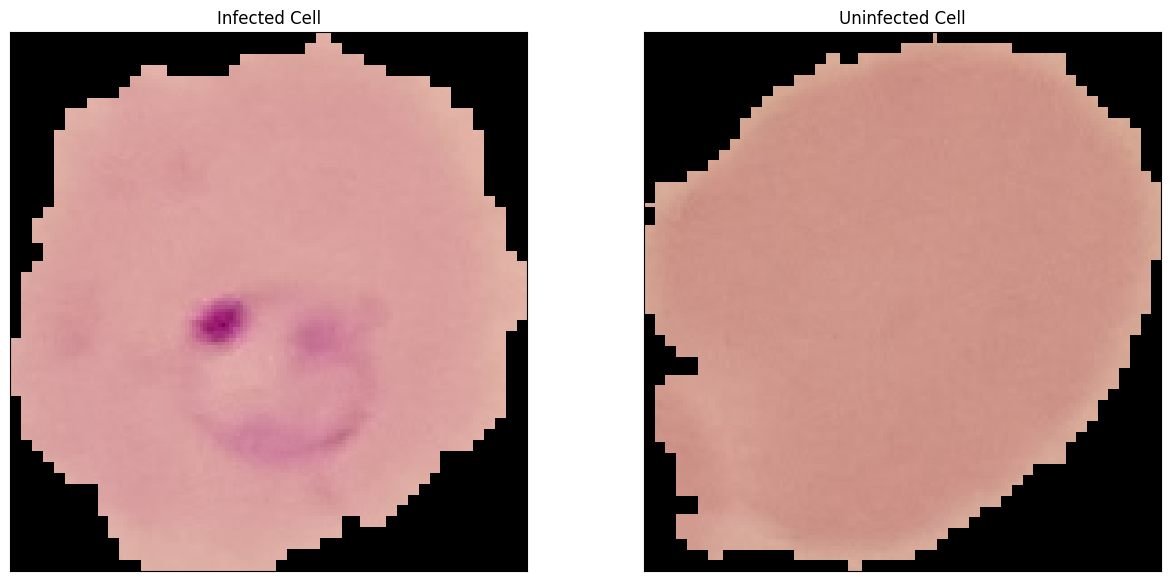

In [8]:
plt.figure(1, figsize = (15 , 7))
plt.subplot(1 , 2 , 1)
plt.imshow(cv2.imread(cells_path[0])[:, :, ::-1])
plt.title('Infected Cell')
plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 2 , 2)
plt.imshow(cv2.imread(cells_path[16000])[:, :, ::-1])
plt.title('Uninfected Cell')
plt.xticks([]) , plt.yticks([])

plt.show()

In [9]:
n = np.arange(cells_path.shape[0])
np.random.seed(42)
np.random.shuffle(n)
cells = cells_path[n]
labels = labels[n]

In [10]:
np.save('shuffled_Cells' , cells)
np.save('shuffled_Labels' , labels)

In [11]:
cells = np.load('shuffled_Cells.npy')
labels = np.load('shuffled_Labels.npy')

# Data Augmentation

In [36]:
# Data augmentation
initial_Augmentation_50 = A.Compose([
    A.Resize(50, 50),
    A.SomeOf([
    A.Rotate(limit=75, p=0.5),
    A.Blur(blur_limit=5, p=0.5),
],n=1,p=1.0),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

initial_val_test_Augmentation_50 = A.Compose([
    A.Resize(50, 50),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

# Data augmentation
initial_Augmentation_128 = A.Compose([
    A.Resize(128, 128),
    A.SomeOf([
    A.Rotate(limit=75, p=0.5),
    A.Blur(blur_limit=5, p=0.5),
],n=1,p=1.0),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

initial_val_test_Augmentation_128 = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

improved_train_Augmentation_50 = A.Compose([
    A.Resize(50, 50),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3), 
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

improved_val_test_Augmentation_50 = A.Compose([
    A.Resize(50, 50),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

improved_train_Augmentation_128 = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3), 
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

improved_val_test_Augmentation_128 = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

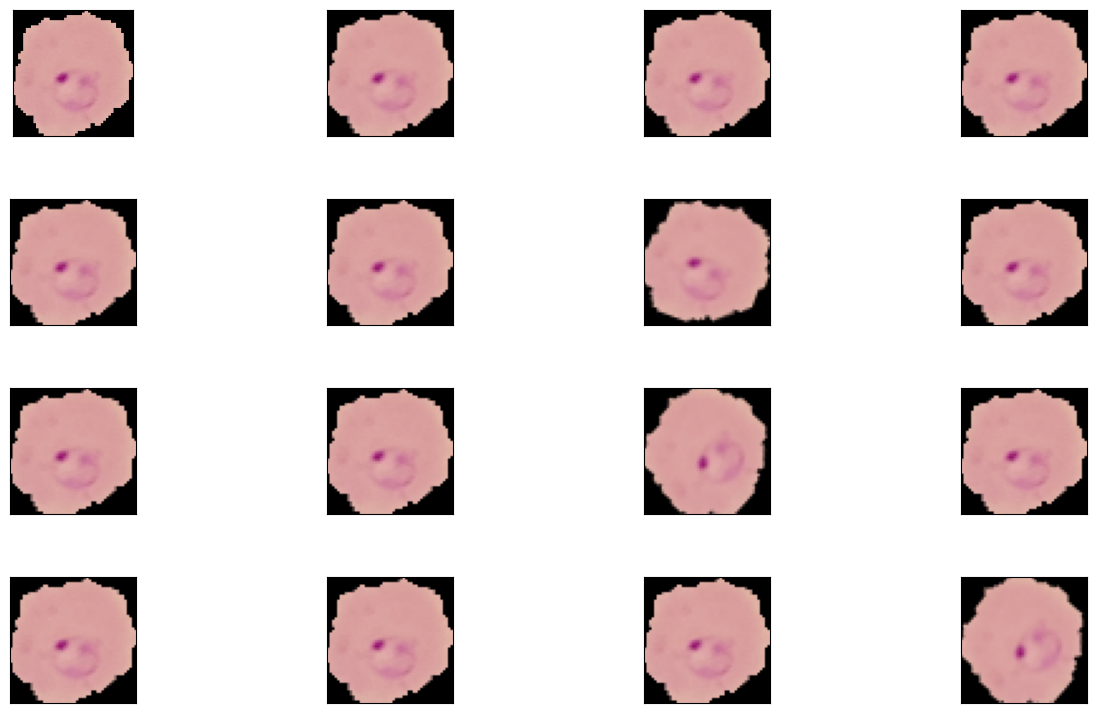

In [13]:
# Examples of variations of the image with initial augmentaion
im1 = cv2.imread(cells_path[0])[:, :, ::-1]
images_list = [im1]
im1 = np.array(im1)

for i in range(15):
    augmentation = initial_Augmentation_50(image=im1)
    augmented_image = augmentation['image']
    images_list.append(augmented_image)

plt.figure(1 , figsize = (15 , 9))
n = 0
for i in range(16):
    n += 1 
    plt.subplot(4 , 4 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(images_list[i])
    plt.xticks([]) , plt.yticks([])
plt.show()


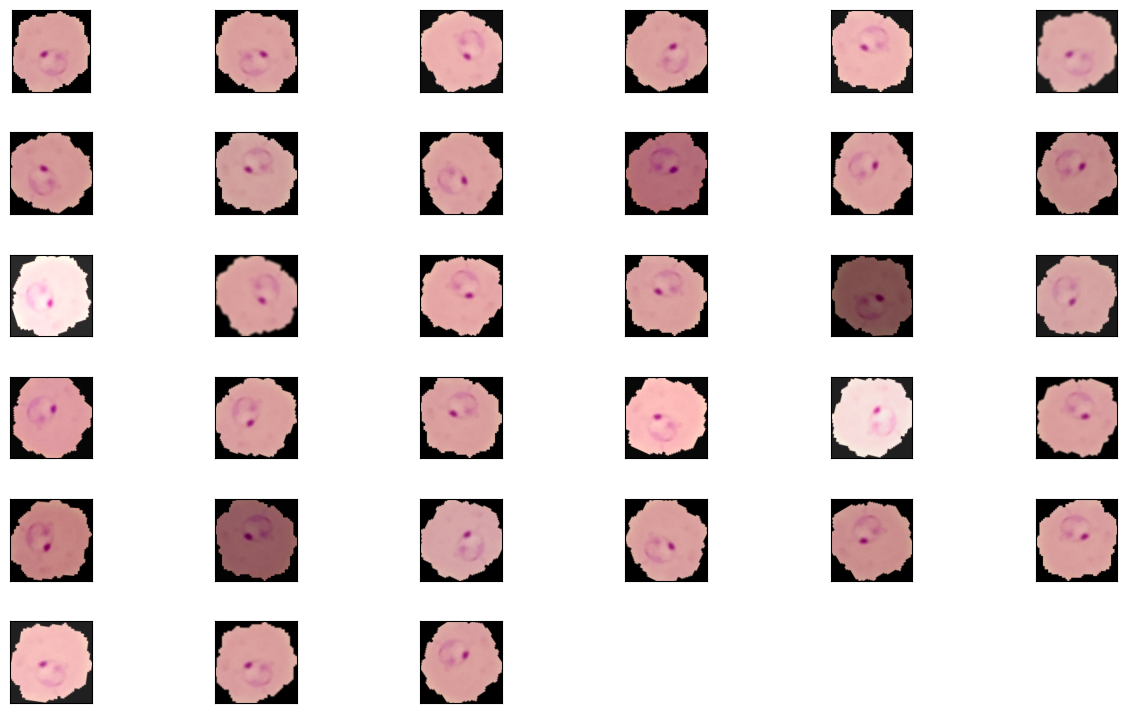

In [ ]:
# Examples of variations of the image with new augmentaion
im1 = cv2.imread(cells_path[0])[:, :, ::-1]
images_list = [im1]
im1 = np.array(im1)

for i in range(32):
    augmentation = improved_train_Augmentation_128(image=im1)
    augmented_image = augmentation['image']
    images_list.append(augmented_image)

plt.figure(1 , figsize = (15 , 9))
n = 0
for i in range(33):
    n += 1 
    plt.subplot(6 , 6 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(images_list[i])
    plt.xticks([]) , plt.yticks([])
plt.show()

# Data Generator

In [15]:
class DataGenerator(Sequence):
    def __init__(self, image_path, labels, batch_size=32, transform=None, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.image_path = image_path
        self.labels = labels
        self.batch_size = batch_size
        self.transform = transform
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_path))
        self.on_epoch_end()

    def __len__(self):
        return(int(np.ceil(len(self.image_path)/self.batch_size)))
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.RandomState(42)
            np.random.shuffle(self.indices)
    
    def __getitem__(self, index):
        index_start = index * self.batch_size
        index_end = (index + 1) * self.batch_size
        batch_indices = self.indices[index_start:index_end]

        images = []
        batch_labels = []

        for i in batch_indices:
            path = self.image_path[i]
            label = self.labels[i]

            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if self.transform:
                augmented = self.transform(image=img)
                img = augmented['image'] 
            
            images.append(img)
            batch_labels.append(label)

        return np.array(images), np.array(batch_labels)

# Training and Test Splits

In [16]:
from sklearn.model_selection import train_test_split

Train_x , test_x , Train_y , test_y = train_test_split(cells , labels , 
                                            test_size = 0.2 ,
                                            random_state = 42)

train_x , eval_x , train_y , eval_y = train_test_split(Train_x , Train_y , 
                                                    test_size = 0.2 , 
                                                    random_state = 42)

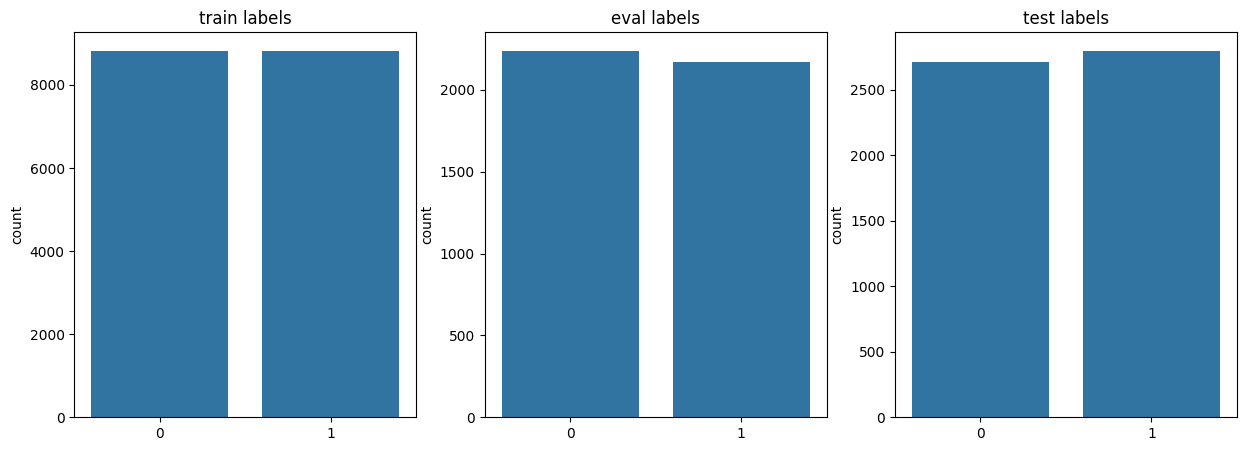

In [17]:
plt.figure(1 , figsize = (15 ,5))
n = 0 
for z , j in zip([train_y , eval_y , test_y] , ['train labels','eval labels','test labels']):
    n += 1
    plt.subplot(1 , 3  , n)
    sns.countplot(x = z )
    plt.title(j)
plt.show()

In [18]:
print('train data shape {} ,eval data shape {} , test data shape {}'.format(train_x.shape,
                                                                           eval_x.shape ,
                                                                           test_x.shape))

train data shape (17636,) ,eval data shape (4410,) , test data shape (5512,)


# Model Architecture

In [48]:
def build_model(resize_shape=(128, 128, 3)):
    model = Sequential([
        Input(shape=resize_shape),
        
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(64, activation='relu'), 
        Dropout(0.5), 
        Dense(1, activation='sigmoid') 
    ])
    
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [22]:
# def build_model(resize_shape=(128, 128, 3)):
#     model = Sequential([
    
#         Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=resize_shape),
#         MaxPooling2D((2, 2)),
#         BatchNormalization(),
#         Dropout(0.3),

#         Conv2D(64, (3, 3), activation='relu', padding='same'),
#         MaxPooling2D((2, 2)),
      
#         GlobalAveragePooling2D(),
#         Dense(512, activation='relu'),
#         BatchNormalization(), 
#         Dropout(0.3), 
#         Dense(256, activation='relu'),
#         BatchNormalization(), 
#         Dense(1, activation='sigmoid'), 
#     ])
    
#     model.compile(
#         optimizer='adam', 
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )
    
#     return model

# First Objective

We are going to find if using a better resolution of the image can improve the accuracy of the model.

First we are going to see with the reduced data augmentation inspired by the author which is the more performant using cross validation

In [49]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_accuracies_50 = []
val_accuracies_128 = []
val_losses_50 = []
val_losses_128 = []

for train_index, val_index in kf.split(Train_x):
    train_x_fold, val_x_fold = Train_x[train_index], Train_x[val_index]
    train_y_fold, val_y_fold = Train_y[train_index], Train_y[val_index]

    train_generator_50 = DataGenerator(train_x_fold, train_y_fold, batch_size=32, transform=initial_Augmentation_50, shuffle=True)
    val_generator_50 = DataGenerator(val_x_fold, val_y_fold, batch_size=32, transform=initial_val_test_Augmentation_50, shuffle=False)
    train_generator_128 = DataGenerator(train_x_fold, train_y_fold, batch_size=32, transform=initial_Augmentation_128, shuffle=True)
    val_generator_128 = DataGenerator(val_x_fold, val_y_fold, batch_size=32, transform=initial_val_test_Augmentation_128, shuffle=False)

    print("Training with 50x50 images...")
    K.clear_session()
    model_50 = build_model((50, 50, 3))
    history_50 = model_50.fit(train_generator_50, validation_data=val_generator_50, epochs=10, verbose=0)
    val_accuracies_50.append(history_50.history['val_accuracy'][-1])
    val_losses_50.append(history_50.history['val_loss'][-1])
    K.clear_session()
    print("Training with 128x128 images...")
    model_128 = build_model((128, 128, 3))
    history_128 = model_128.fit(train_generator_128, validation_data=val_generator_128, epochs=10, verbose=0)
    val_accuracies_128.append(history_128.history['val_accuracy'][-1])
    val_losses_128.append(history_128.history['val_loss'][-1])

print(f"Average Validation Accuracy (50x50): {np.mean(val_accuracies_50):.4f} ± {np.std(val_accuracies_50):.4f}")
print(f"Average Validation Loss (50x50): {np.mean(val_losses_50):.4f} ± {np.std(val_losses_50):.4f}")


print(f"Average Validation Accuracy (128x128): {np.mean(val_accuracies_128):.4f} ± {np.std(val_accuracies_128):.4f}")
print(f"Average Validation Loss (128x128): {np.mean(val_losses_128):.4f} ± {np.std(val_losses_128):.4f}")



Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Average Validation Accuracy (50x50): 0.9578 ± 0.0040
Average Validation Loss (50x50): 0.1258 ± 0.0099
Average Validation Accuracy (128x128): 0.9579 ± 0.0024
Average Validation Loss (128x128): 0.1358 ± 0.0081


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_accuracies_50 = []
val_accuracies_128 = []
val_losses_50 = []
val_losses_128 = []

for train_index, val_index in kf.split(Train_x):
    train_x_fold, val_x_fold = Train_x[train_index], Train_x[val_index]
    train_y_fold, val_y_fold = Train_y[train_index], Train_y[val_index]

    train_generator_50 = DataGenerator(train_x_fold, train_y_fold, batch_size=32, transform=improved_train_Augmentation_50, shuffle=True)
    val_generator_50 = DataGenerator(val_x_fold, val_y_fold, batch_size=32, transform=improved_val_test_Augmentation_50, shuffle=False)
    train_generator_128 = DataGenerator(train_x_fold, train_y_fold, batch_size=32, transform=improved_train_Augmentation_128, shuffle=True)
    val_generator_128 = DataGenerator(val_x_fold, val_y_fold, batch_size=32, transform=improved_val_test_Augmentation_128, shuffle=False)

    print("Training with 50x50 images...")
    K.clear_session()
    model_50 = build_model((50, 50, 3))
    history_50 = model_50.fit(train_generator_50, validation_data=val_generator_50, epochs=10, verbose=0)
    val_accuracies_50.append(history_50.history['val_accuracy'][-1])
    val_losses_50.append(history_50.history['val_loss'][-1])
    K.clear_session()
    print("Training with 128x128 images...")
    model_128 = build_model((128, 128, 3))
    history_128 = model_128.fit(train_generator_128, validation_data=val_generator_128, epochs=10, verbose=0)
    val_accuracies_128.append(history_128.history['val_accuracy'][-1])
    val_losses_128.append(history_128.history['val_loss'][-1])

print(f"Average Validation Accuracy (50x50): {np.mean(val_accuracies_50):.4f} ± {np.std(val_accuracies_50):.4f}")
print(f"Average Validation Loss (50x50): {np.mean(val_losses_50):.4f} ± {np.std(val_losses_50):.4f}")


print(f"Average Validation Accuracy (128x128): {np.mean(val_accuracies_128):.4f} ± {np.std(val_accuracies_128):.4f}")
print(f"Average Validation Loss (128x128): {np.mean(val_losses_128):.4f} ± {np.std(val_losses_128):.4f}")



Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Training with 50x50 images...
Training with 128x128 images...
Average Validation Accuracy (50x50): 0.9571 ± 0.0038
Average Validation Loss (50x50): 0.1239 ± 0.0094
Average Validation Accuracy (128x128): 0.9552 ± 0.0041
Average Validation Loss (128x128): 0.1342 ± 0.0121


# Second Objective

Then find wich combination of hyperparameters can improve the accuracy of the model.

In [ ]:
train_generator = DataGenerator(train_x, train_y, batch_size=32, transform=improved_train_Augmentation_128, shuffle=True)
val_generator = DataGenerator(eval_x, eval_y, batch_size=32, transform=improved_val_test_Augmentation_128, shuffle=False)
test_generator = DataGenerator(test_x, test_y, batch_size=32, transform=improved_val_test_Augmentation_128, shuffle= False)

First Lets find the optimal number of convolutional layers and their sizes

In [ ]:
# Hyperparameters to test
dense_layers = [0, 1, 2]
layer_sizes = [32, 64, 128]
conv_layers = [1, 2, 3]
dense_nodes = [64, 128]
resize_shape = (128, 128, 3)


# First Lets find the optimal number of convolutional layers and their sizes

nb_of_models = sum([len(layer_sizes)**c for c in conv_layers])
print(f"Total number of models to test: {nb_of_models}")

# Restarts from where it has stopped
target_conv_layer = 3
target_conv_sizes = (128, 64, 32)
skip_models = True

for conv_layer in conv_layers:
    layers_combination = list(itertools.product(layer_sizes, repeat=conv_layer))
    for conv_sizes in layers_combination:    
            if skip_models:
                if conv_layer == target_conv_layer and conv_sizes == target_conv_sizes:
                    print(f"Resuming from model with {conv_layer} convolutional layers and sizes {conv_sizes}")
                    skip_models = False
                else:
                    continue

            K.clear_session()
            
            NAME = f"model Conv {conv_layer}-{conv_sizes}-Dense 0---{int(time.time())}"
            print(NAME)
            
            tensorboard = TensorBoard(log_dir=os.path.join("logs", NAME))

            model = Sequential()

            model.add(Input(shape=resize_shape))
            model.add(Conv2D(conv_sizes[0], (3, 3), activation='relu', padding='same'))
            model.add(MaxPooling2D((2, 2)))

            for l in range(conv_layer - 1):
                model.add(Conv2D(conv_sizes[l+1], (3, 3), activation='relu', padding='same'))
                model.add(MaxPooling2D((2, 2)))
            
            model.add(Flatten())
            
            model.add(Dense(1, activation='sigmoid'))

            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

            model.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=[tensorboard])

We come at the conclusion that the optimal number of convolutional layers is 3. Now we will find the optimal number of dense layers and their sizes.

In [22]:
# Hyperparameters to test
dense_layers = [1, 2]
layer_sizes = [32, 64, 128]
conv_layers = [3]
dense_nodes = [64, 128]
resize_shape = (128, 128, 3)


# First Lets find the optimal number of convolutional layers and their sizes

nb_of_models = sum([len(dense_nodes)**d * len(layer_sizes)**c for d in dense_layers for c in conv_layers])
print(f"Total number of models to test: {nb_of_models}")


for dense_size in dense_layers:
    dense_nodes_combination = list(itertools.product(dense_nodes, repeat=dense_size))
    for dense_nodes in dense_nodes_combination:
        for conv_layer in conv_layers:
            layers_combination = list(itertools.product(layer_sizes, repeat=conv_layer))
            for conv_sizes in layers_combination:    

                    K.clear_session()
                    
                    NAME = f"model Conv {conv_layer}-{conv_sizes}-Dense  {dense_size}-{dense_nodes}---{int(time.time())}"
                    print(NAME)
                    
                    tensorboard = TensorBoard(log_dir=os.path.join("logs", NAME))

                    model = Sequential()

                    model.add(Input(shape=resize_shape))
                    model.add(Conv2D(conv_sizes[0], (3, 3), activation='relu', padding='same'))
                    model.add(MaxPooling2D((2, 2)))

                    for l in range(conv_layer - 1):
                        model.add(Conv2D(conv_sizes[l+1], (3, 3), activation='relu', padding='same'))
                        model.add(MaxPooling2D((2, 2)))
                    
                    model.add(Flatten())
                    for d in range(dense_size):
                        model.add(Dense(dense_nodes[d], activation='relu'))
                        model.add(Dropout(0.5))
                    model.add(Dense(1, activation='sigmoid'))

                    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

                    model.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=[tensorboard])


Total number of models to test: 162

model Conv 3-(32, 32, 32)-Dense  1-(64,)---1772818194
Epoch 1/5
181/552 ━━━━━━━━━━━━━━━━━━━━ 47s 129ms/step - accuracy: 0.5319 - loss: 0.6919

KeyboardInterrupt: 

In [ ]:
# Hyperparameters to test
dense_layers = [1, 2]
layer_sizes = [32, 64, 128]
conv_layers = [3]
dense_nodes = [64, 128]
resize_shape = (128, 128, 3)


# First Lets find the optimal number of convolutional layers and their sizes

nb_of_models = sum([len(dense_nodes)**d * len(layer_sizes)**c for d in dense_layers for c in conv_layers])
print(f"Total number of models to test: {nb_of_models}")


for dense_size in dense_layers:
    dense_nodes_combination = list(itertools.product(dense_nodes, repeat=dense_size))
    for dense_nodes in dense_nodes_combination:
        for conv_layer in conv_layers:
            layers_combination = list(itertools.product(layer_sizes, repeat=conv_layer))
            for conv_sizes in layers_combination:    

                    K.clear_session()
                    
                    NAME = f"model Conv {conv_layer}-{conv_sizes}-Dense  {dense_size}-{dense_nodes}---{int(time.time())}"
                    print(NAME)
                    
                    tensorboard = TensorBoard(log_dir=os.path.join("logs", NAME))

                    model = Sequential()

                    model.add(Input(shape=resize_shape))
                    model.add(Conv2D(conv_sizes[0], (3, 3), activation='relu', padding='same'))
                    model.add(MaxPooling2D((2, 2)))

                    for l in range(conv_layer - 1):
                        model.add(Conv2D(conv_sizes[l+1], (3, 3), activation='relu', padding='same'))
                        model.add(MaxPooling2D((2, 2)))
                    
                    model.add(Flatten())
                    for d in range(dense_size):
                        model.add(Dense(dense_nodes[d], activation='relu'))
                        model.add(Dropout(0.5))
                    model.add(Dense(1, activation='sigmoid'))

                    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

                    model.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=[tensorboard])


Total number of models to test: 162
model Conv 3-(32, 32, 32)-Dense  1-(64,)---1772467776
Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 117s 209ms/step - accuracy: 0.6415 - loss: 0.6148 - val_accuracy: 0.9154 - val_loss: 0.2688
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 78s 142ms/step - accuracy: 0.9298 - loss: 0.2332 - val_accuracy: 0.9556 - val_loss: 0.1425
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 137s 248ms/step - accuracy: 0.9450 - loss: 0.1830 - val_accuracy: 0.9574 - val_loss: 0.1344
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 78s 141ms/step - accuracy: 0.9507 - loss: 0.1645 - val_accuracy: 0.9472 - val_loss: 0.1579
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 76s 137ms/step - accuracy: 0.9523 - loss: 0.1610 - val_accuracy: 0.9619 - val_loss: 0.1300
model Conv 3-(32, 32, 64)-Dense  1-(64,)---1772468263
Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 87s 155ms/step - accuracy: 0.7993 - loss: 0.4225 - val_accuracy: 0.9363 - val_loss: 0.1654
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 84s 153ms/step - accuracy: 0.9389 -

## Results: Top 10 Best Performing Models

| Rank | Conv Layers (filters) | Dense Layers (nodes) |
|:----:|:---------------------:|:--------------------:|
| 1 | Conv3-(64, 32, 64) | Dense2-(128, 64) |
| 2 | Conv3-(128, 32, 32) | Dense1-(128,) |
| 3 | Conv3-(32, 32, 64) | Dense2-(64, 64) |
| 4 | Conv3-(64, 32, 32) | Dense2-(64, 64) |
| 5 | Conv3-(32, 32, 32) | Dense1-(64, 64) |
| 6 | Conv3-(128, 64, 64) | Dense1-(64,) |
| 7 | Conv3-(128, 32, 32) | Dense2-(128, 64) |
| 8 | Conv3-(64, 32, 64) | Dense1-(64,) |
| 9 | Conv3-(64, 32, 128) | Dense1-(64,) |
| 10 | Conv3-(64, 64, 64) | Dense1-(64,) |

In [30]:
# Top 10 models configurations (index = rank - 1)
top_models = [
    {"conv_sizes": (64, 32, 64),   "dense_layers": 2, "dense_nodes": (128, 64)},   # Rank 1
    {"conv_sizes": (128, 32, 32),  "dense_layers": 1, "dense_nodes": (128,)},      # Rank 2
    {"conv_sizes": (32, 32, 64),   "dense_layers": 2, "dense_nodes": (64, 64)},    # Rank 3
    {"conv_sizes": (64, 32, 32),   "dense_layers": 2, "dense_nodes": (64, 64)},    # Rank 4
    {"conv_sizes": (32, 32, 32),   "dense_layers": 1, "dense_nodes": (64, 64)},    # Rank 5
    {"conv_sizes": (128, 64, 64),  "dense_layers": 1, "dense_nodes": (64,)},       # Rank 6
    {"conv_sizes": (128, 32, 32),  "dense_layers": 2, "dense_nodes": (128, 64)},   # Rank 7
    {"conv_sizes": (64, 32, 64),   "dense_layers": 1, "dense_nodes": (64,)},       # Rank 8
    {"conv_sizes": (64, 32, 128),  "dense_layers": 1, "dense_nodes": (64,)},       # Rank 9
    {"conv_sizes": (64, 64, 64),   "dense_layers": 1, "dense_nodes": (64,)},       # Rank 10
]


# Top 10 models Evaluations

Now that we have found the bests models, we are going to find which one of them is the best by comparing them in cross validation. When we have found the best one, we are going to train it  with all the training data and look at its performance with the test data. 

In [60]:
def create_model(model_parameters, input_shape=(128, 128, 3)):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    for conv_size in model_parameters["conv_sizes"]:
        model.add(Conv2D(conv_size, (3, 3), activation='relu', padding='same'))
        model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    
    for d in range(model_parameters["dense_layers"]):
        model.add(Dense(model_parameters["dense_nodes"][d], activation='relu'))
        model.add(Dropout(0.5))
    
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Recall(name='recall'), Precision(name='precision')])
    
    return model

In [61]:
from sklearn.model_selection import KFold

top_models_results = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
for i, top_model in enumerate(top_models):
    top_model_values = {
    "val_accuracies": [],
    "val_losses": [],
    "val_recalls": [],
    "val_precisions": [],
    "val_f1_scores": []
    }
    print(f"Evaluating Top Model {i+1} with configuration: Conv Sizes {top_model['conv_sizes']}, Dense Layers {top_model['dense_layers']}, Dense Nodes {top_model['dense_nodes']}")
    for train_index, val_index in kf.split(Train_x):
        train_x_fold, val_x_fold = Train_x[train_index], Train_x[val_index]
        train_y_fold, val_y_fold = Train_y[train_index], Train_y[val_index]

        train_generator = DataGenerator(train_x_fold, train_y_fold, batch_size=32, transform=improved_train_Augmentation_128, shuffle=True)
        val_generator = DataGenerator(val_x_fold, val_y_fold, batch_size=32, transform=improved_val_test_Augmentation_128, shuffle=False)

        K.clear_session()
        model = create_model(top_model, input_shape=(128, 128, 3))
        h = model.fit(train_generator, validation_data=val_generator, epochs=5)
        top_model_values["val_losses"].append(h.history['val_loss'])
        top_model_values["val_accuracies"].append(h.history['val_accuracy'])
        top_model_values["val_recalls"].append(h.history['val_recall'])
        top_model_values["val_precisions"].append(h.history['val_precision'])

    print(f"Results for Top Model {i+1}:")
    print(f"Average Validation Accuracy : {np.mean(top_model_values['val_accuracies']):.4f} ± {np.std(top_model_values['val_accuracies']):.4f}")
    print(f"Average Validation Loss: {np.mean(top_model_values['val_losses']):.4f} ± {np.std(top_model_values['val_losses']):.4f}")
    print(f"Average Validation Recall: {np.mean(top_model_values['val_recalls']):.4f} ± {np.std(top_model_values['val_recalls']):.4f}")
    print(f"Average Validation Precision: {np.mean(top_model_values['val_precisions']):.4f} ± {np.std(top_model_values['val_precisions']):.4f}")
    top_models_results[f"Model {i+1}"] = top_model_values




Evaluating Top Model 1 with configuration: Conv Sizes (64, 32, 64), Dense Layers 2, Dense Nodes (128, 64)
Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 271s 486ms/step - accuracy: 0.5333 - loss: 0.6897 - precision: 0.5298 - recall: 0.5847 - val_accuracy: 0.5658 - val_loss: 0.6742 - val_precision: 0.5814 - val_recall: 0.4198
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 122s 221ms/step - accuracy: 0.7937 - loss: 0.4162 - precision: 0.7830 - recall: 0.8121 - val_accuracy: 0.9562 - val_loss: 0.1380 - val_precision: 0.9626 - val_recall: 0.9479
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 119s 216ms/step - accuracy: 0.9474 - loss: 0.1785 - precision: 0.9573 - recall: 0.9364 - val_accuracy: 0.9578 - val_loss: 0.1359 - val_precision: 0.9584 - val_recall: 0.9558
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 122s 222ms/step - accuracy: 0.9491 - loss: 0.1702 - precision: 0.9546 - recall: 0.9429 - val_accuracy: 0.9592 - val_loss: 0.1252 - val_precision: 0.9632 - val_recall: 0.9535
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 118

In [62]:
# Cross Validation Results Analysis
def get_stats(values):
    return f"{np.mean(values):.4f} ± {np.std(values):.4f}"

def find_best(metric, maximize=True):
    func = max if maximize else min
    best_model = func(top_models_results, key=lambda x: np.mean(top_models_results[x][metric]))
    return best_model, get_stats(top_models_results[best_model][metric])

# Display all results
print("Different models results:")
for model_name, r in top_models_results.items():
    print(f"{model_name} - Acc: {get_stats(r['val_accuracies'])}, Loss: {get_stats(r['val_losses'])}, "
          f"Recall: {get_stats(r['val_recalls'])}, Precision: {get_stats(r['val_precisions'])}")

# Summary of best models
print("\nSummary of the best models:")
metrics = [
    ("Accuracy", "val_accuracies", True),
    ("Recall", "val_recalls", True),
    ("Precision", "val_precisions", True)
]

for name, key, maximize in metrics:
    best, stats = find_best(key, maximize)
    print(f"Best {name}: {best} ({stats})")

# Optionally add F1-score
def get_f1(model_name):
    r = top_models_results[model_name]
    recall = np.mean(r['val_recalls'])
    precision = np.mean(r['val_precisions'])
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

best_f1_model = max(top_models_results, key=get_f1)
print(f"Best F1-score: {best_f1_model} ({get_f1(best_f1_model):.4f})")

Different models results:
Model 1 - Acc: 0.9115 ± 0.1078, Loss: 0.2152 ± 0.1622, Recall: 0.9117 ± 0.1071, Precision: 0.9177 ± 0.1174
Model 2 - Acc: 0.9500 ± 0.0090, Loss: 0.1606 ± 0.0226, Recall: 0.9338 ± 0.0191, Precision: 0.9651 ± 0.0177
Model 3 - Acc: 0.9369 ± 0.0726, Loss: 0.1773 ± 0.1049, Recall: 0.9266 ± 0.0967, Precision: 0.9433 ± 0.0684
Model 4 - Acc: 0.9033 ± 0.1129, Loss: 0.2399 ± 0.1784, Recall: 0.8968 ± 0.1383, Precision: 0.9088 ± 0.1203
Model 5 - Acc: 0.9484 ± 0.0110, Loss: 0.1615 ± 0.0237, Recall: 0.9358 ± 0.0146, Precision: 0.9602 ± 0.0196
Model 6 - Acc: 0.9466 ± 0.0193, Loss: 0.1659 ± 0.0493, Recall: 0.9268 ± 0.0412, Precision: 0.9649 ± 0.0115
Model 7 - Acc: 0.9192 ± 0.1041, Loss: 0.2034 ± 0.1437, Recall: 0.9153 ± 0.1274, Precision: 0.9260 ± 0.1033
Model 8 - Acc: 0.8590 ± 0.1805, Loss: 0.2625 ± 0.2163, Recall: 0.7460 ± 0.3733, Precision: 0.7714 ± 0.3860
Model 9 - Acc: 0.9493 ± 0.0089, Loss: 0.1595 ± 0.0196, Recall: 0.9376 ± 0.0119, Precision: 0.9600 ± 0.0169
Model 10 - 

From here, we can see what are the best model for accuracy, recall and precision. 

When trying to find the infected patient we want to maximize the recall to not miss any infected patient. 

The best precision model will be the one that will minimize the number of false positives.

And the best accuracy model will be the one that will maximize the number of correct predictions which happend to also be the best f1 score model. It means that, it is the perfect balance between precision and recall.



Now, Lets evaluate the performance of those 3 models on the test set.

In [63]:
# Test
best_models = [2,10]
best_model_stats = {
    2 : {},
    10 : {}
}

for best_model in best_models : 
    testing_model_param = top_models[best_model - 1]
    testing_model = create_model(testing_model_param)
    train_generator = DataGenerator(Train_x, Train_y, batch_size=32, transform=improved_train_Augmentation_128,shuffle=True)
    test_generator = DataGenerator(test_x, test_y, batch_size=32, transform=improved_val_test_Augmentation_128, shuffle=False)
    h = testing_model.fit(train_generator, validation_data=test_generator, epochs=10)
    best_model_stats[best_model]["Accuracy"] = h.history['val_accuracy']
    best_model_stats[best_model]["Precision"] = h.history['val_precision']
    best_model_stats[best_model]["Recall"] = h.history['val_recall']
    # Calculate F1 from precision and recall
    prec = h.history['val_precision'][-1]
    rec = h.history['val_recall'][-1]
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    best_model_stats[best_model]["F1-Score"] = f1

    print(f"\nTest results for Model {best_model}:")
    print(f"Precision: {best_model_stats[best_model]['Precision'][-1]}")
    print(f"Accuracy: {best_model_stats[best_model]['Accuracy'][-1]}")
    print(f"Recall: {best_model_stats[best_model]['Recall'][-1]}")
    print(f"F1-Score: {best_model_stats[best_model]['F1-Score']}")
    print("-" * 30)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 438s 632ms/step - accuracy: 0.6664 - loss: 0.5839 - precision: 0.6645 - recall: 0.6668 - val_accuracy: 0.9263 - val_loss: 0.1996 - val_precision: 0.9318 - val_recall: 0.9225
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 379s 550ms/step - accuracy: 0.9349 - loss: 0.1983 - precision: 0.9423 - recall: 0.9260 - val_accuracy: 0.9356 - val_loss: 0.1902 - val_precision: 0.9845 - val_recall: 0.8871
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 269s 390ms/step - accuracy: 0.9501 - loss: 0.1664 - precision: 0.9625 - recall: 0.9362 - val_accuracy: 0.9579 - val_loss: 0.1337 - val_precision: 0.9679 - val_recall: 0.9486
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 286s 415ms/step - accuracy: 0.9508 - loss: 0.1601 - precision: 0.9613 - recall: 0.9390 - val_accuracy: 0.9557 - val_loss: 0.1376 - val_precision: 0.9776 - val_recall: 0.9343
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 263s 381ms/step - accuracy: 0.9537 - loss: 0.1484 - precision: 0.9636 - recall: 0.9427 - val_accuracy: 0

In [53]:
print(h.history.keys())

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1'])
